# InDepth: K-Means Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

In [2]:
# Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

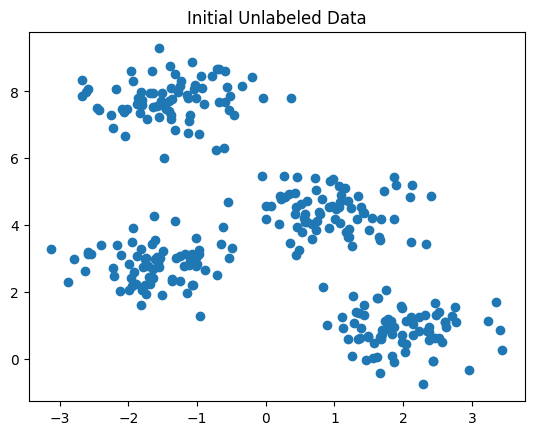

In [5]:
# Display the data
plt.scatter(X[:, 0], X[:, 1])
plt.title("Initial Unlabeled Data")
plt.show()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# Elbow method to find optimal value of k
wcss = [] # Sum of squared distances (inertia)
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k) # n_init is default, ensures best run is chosen
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


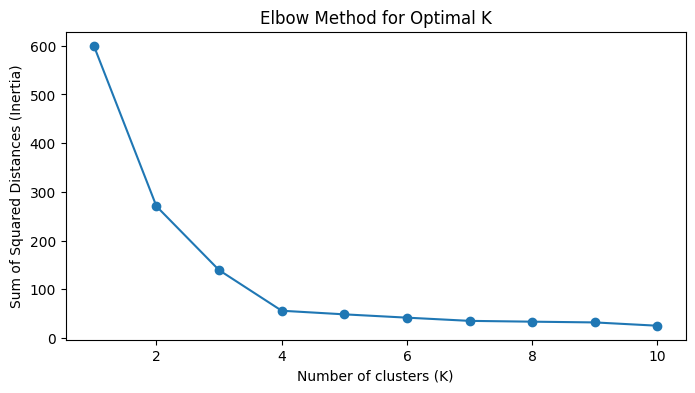

In [8]:
# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.show()


In [9]:
# Initialize and fit the KMeans model
kmeans_model = KMeans(n_clusters=4)
kmeans_model.fit(X_scaled)

KMeans(n_clusters=4)

In [10]:
# Get the cluster assignments (labels) and centroids
y_kmeans = kmeans_model.predict(X_scaled)
centroids = kmeans_model.cluster_centers_

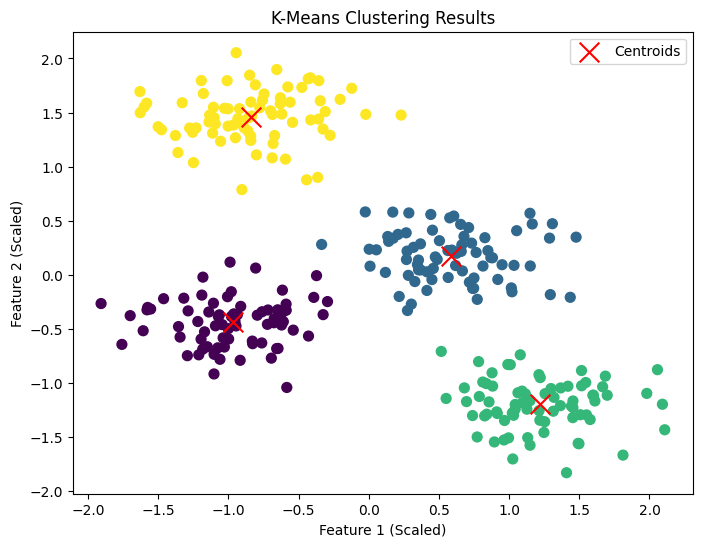

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='x', label='Centroids')
plt.title('K-Means Clustering Results')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.show()

## Example: Customer segmentation using K-Means

Goal: Grouping customers based on behaviour, so bussiness can target them better

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [13]:
import seaborn as sns

In [14]:
df = pd.read_csv('Dataset/archive/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Income based clustering

In [15]:
# Select features (grouping based on Annual Income and Spending Score)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

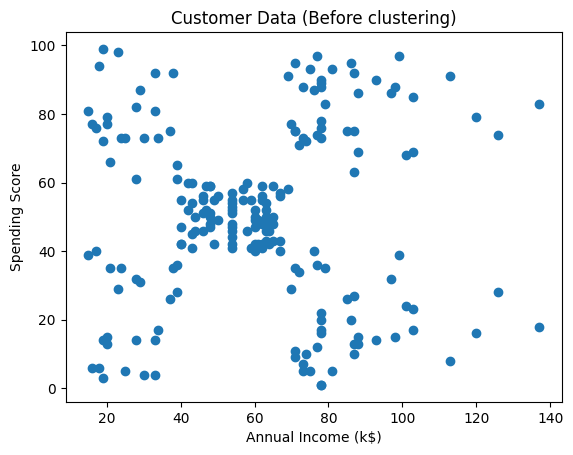

In [16]:
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Data (Before clustering)')
plt.show()

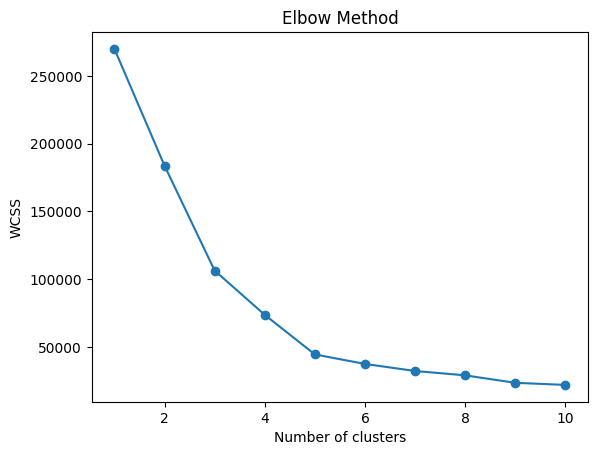

In [17]:
# Elbow method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [18]:
# Apply Kmean
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)

KMeans(n_clusters=5)

In [19]:
clusters = kmeans.predict(X)

In [20]:
df['Clusters'] = clusters

In [21]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,0


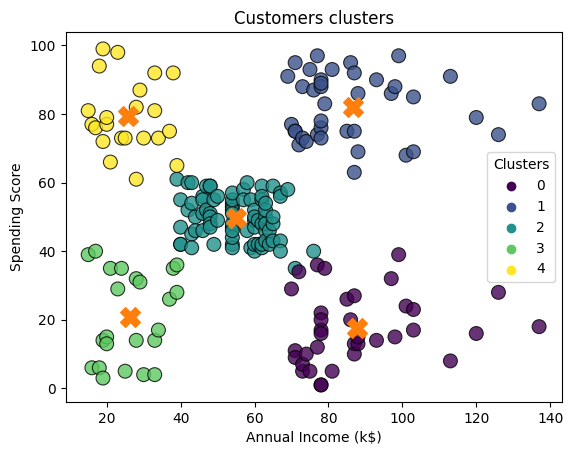

In [22]:
#plt.scatter(X.iloc[:,0], X.iloc[:,1], c=clusters)
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Clusters', palette='viridis', s=100, alpha=0.8, edgecolor='black')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, marker='X')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customers clusters')
plt.show()

In [23]:
# Quantitative Persona Analysis
cluster_profiles = df.groupby('Clusters')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
cluster_profiles['Size'] = df['Clusters'].value_counts()
print("Income-Based Cluster Profiles")
cluster_profiles

Income-Based Cluster Profiles


,Age,Annual Income (k$),Spending Score (1-100),Size
Clusters,,,,
0,40.67,87.75,17.58,36
1,32.69,86.54,82.13,39
2,42.94,55.09,49.71,80
3,45.22,26.30,20.91,23
4,25.27,25.73,79.36,22


Income-Based Personas and Strategy  
Using the quantitative profiles, we can define our segments:  

Cluster 0 (Careful High-Earners): High income (~88k) but low spending (~17). Cautious, value-driven buyers.  
Cluster 1 (Target - High Value): High income (~87k) and high spending (~82). The mall's prime target.  
Cluster 2 (Standard): Average income (~55k) and spending (~50). This is the largest, core customer group.      
Cluster 3 (Budget Shoppers): Low income (~26k) and low spending (~21). Highly price-sensitive.  
Cluster 4 (Enthusiasts): Low income (~26k) but high spending (~79). Likely young, trend-focused shoppers.  

### Age based clustering

In [24]:
X2 = df[['Age', 'Spending Score (1-100)']]


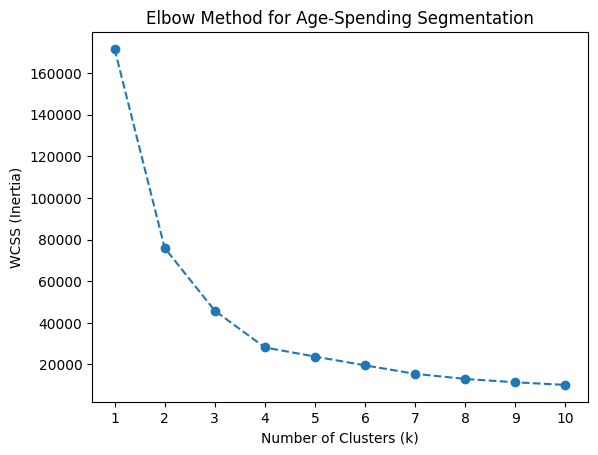

In [25]:
# Implement the Elbow Method
wcss2 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X2)
    wcss2.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
#plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss2, marker='o', linestyle='--')
plt.title('Elbow Method for Age-Spending Segmentation')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

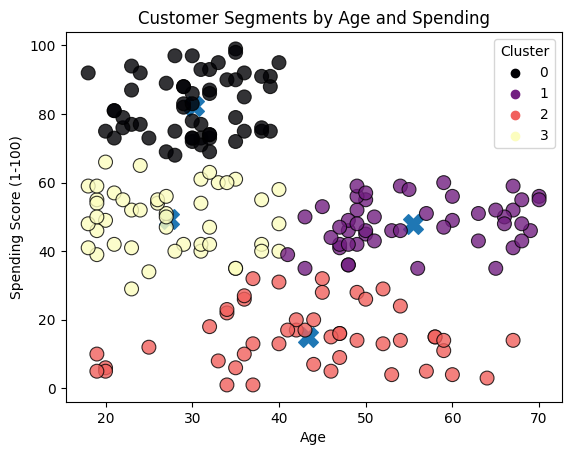

In [27]:
# Build and fit the final model for age segmentation
kmeans2 = KMeans(n_clusters=4)
df['Age_Cluster'] = kmeans2.fit_predict(X2)

# Visualize the new clusters
plt.scatter(kmeans2.cluster_centers_[:,0], kmeans2.cluster_centers_[:,1], s=200, marker='X')
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)',
                hue='Age_Cluster', palette='magma', s=100, alpha=0.8, edgecolor='black')
plt.title('Customer Segments by Age and Spending')
plt.legend(title='Cluster')
plt.show()

Interpreting the Age-Based Segments  
This model gives us a different perspective:  

Young High-Spenders: A clear group of customers under 40 with high spending scores.  
Young Low-Spenders: Customers under 40 with low-to-moderate spending.  
Older Average-Spenders: Customers over 40 with moderate spending scores.  
Older Low-Spenders: A small group of older customers with very low spending scores.  